# Plot:

## Root word counts for elus vs kohad for verbs

verb+comp+case -> elus/koht/total distinct root count

In [1]:
import sqlite3
import pandas as pd
from tqdm import tqdm
import powerlaw as pwl
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

## Configuration

In [2]:
DB_DIR = "../example_data"
PATTERN_MATCHES_DB = f"{DB_DIR}/pattern_matches.db"

TRANSACTIONS_OBL_ACTOR_LOC_COUNTS = "trans_obl_actor_loc_counts"

## Connect to db

In [3]:
con = sqlite3.connect(PATTERN_MATCHES_DB)
cur = con.cursor()

## Workflow

In [5]:
query = """SELECT * from {tbl}""".format(tbl=TRANSACTIONS_OBL_ACTOR_LOC_COUNTS)
source2 = pd.read_sql_query(query, con)
source2.head()

,verb,verb_compound,loc_case,elus_cnt,koht_cnt,root_cnt
0,aitama,,ad,1,0,1
1,elama,välja,adit,0,0,1
2,elama,välja,in,0,0,1
3,helistama,,all,1,0,1
4,helistama,,el,0,0,1


In [3]:
# original data

#query = """SELECT * from {tbl}""".format(tbl=TRANSACTIONS_OBL_ACTOR_LOC_COUNTS)
#source2 = pd.read_sql_query(query, con)
#source2

,verb,verb_compound,kaane,elus_cnt,koht_cnt,root_cnt
0,saama,,el,1274,402,19632
1,andma,,all,1601,250,11612
2,rääkima,,el,802,202,10891
3,saama,,in,134,306,8532
4,tulema,,ad,1134,166,8468
...,...,...,...,...,...,...
74715,šveitsima,,el,0,0,1
74716,švipsima,,ad,0,0,1
74717,žestikuleerima,,ad,0,1,1
74718,žisraelima,,ad,0,0,1


### Normaliseeritud väärtused, filter root_cnt >=100

In [12]:
# mummude suurus
areadict = {}
root_cnts = sorted(list(set(list(source2["root_cnt"])))) # 1-21K

for cnt in root_cnts:
    if cnt <10: areadict[cnt] = 1
    elif cnt >=10 and cnt < 100: areadict[cnt] = 5
    elif cnt >=100 and cnt < 500: areadict[cnt] = 10
    elif cnt >=500 and cnt < 1000: areadict[cnt] = 30
    elif cnt >=1000 and cnt < 2000: areadict[cnt] = 50
    elif cnt >=2000 and cnt < 5000: areadict[cnt] = 80
    elif cnt >=5000 and cnt < 10000: areadict[cnt] = 100
    elif cnt >=10000 and cnt < 15000: areadict[cnt] = 300
    elif cnt >=15000 and cnt < 20000: areadict[cnt] = 500
    elif cnt >=20000: areadict[cnt] = 700


# andmed
elusad = []
kohad = []
roots = []

for i in range(len(source2)):
    if source2.iloc[i]["root_cnt"]>=100:
        roots.append(source2.iloc[i]["root_cnt"])
        kohad.append(source2.iloc[i]["koht_cnt"]/source2.iloc[i]["root_cnt"])
        elusad.append(source2.iloc[i]["elus_cnt"]/source2.iloc[i]["root_cnt"])
        

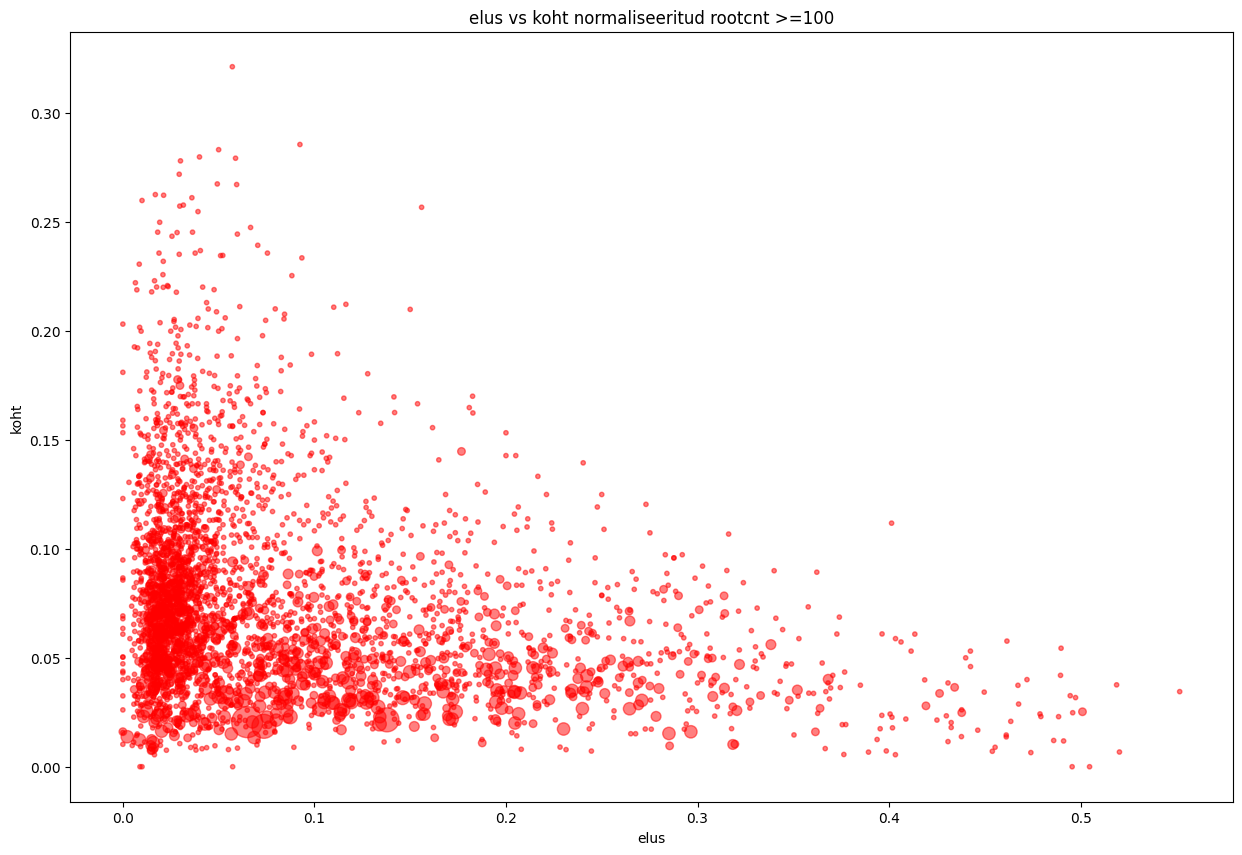

In [6]:
plt.figure(figsize=(15, 10))
x = elusad
y = kohad
area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='r', alpha=0.5)
plt.title("elus vs koht normaliseeritud rootcnt >=100")
plt.ylabel("koht")
plt.xlabel("elus")

plt.show()

In [7]:
con.close()